# Setting

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from api import split_expand
from langchain_openai import ChatOpenAI


llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    # ["2324","仁寶", "tw"],
    # ["4938", "和碩", "tw"],
    # ["2356","英業達", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2412", "中華電", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["6505", "台塑化", "tw"],
    # ["2603", "長榮", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
]

date_range = [
    ["20230401", "20240331"],
    ["20230701", "20240630"],
    ["20231001", "20240930"],
]



# Factor

2330 台積電 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,46,46,30,11,133,185,0.571429,0.500000,0.807018,0.002060,0.001054,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,16,20,7,2,45,56,0.511111,0.444444,0.888889,0.001002,0.000225,"[[20240102, 0.005084745762711864], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,49,56,39,30,174,185,0.505747,0.466667,0.620253,0.001730,0.001021,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,18,19,10,2,49,56,0.571429,0.486486,0.900000,0.001634,0.000606,"[[20240102, 0], [20240103, -0.0102739726027397..."


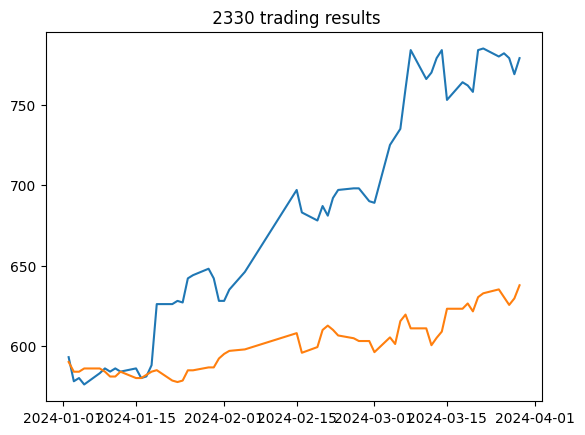

2317 鴻海 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,62,96,16,7,181,185,0.430939,0.392405,0.898551,0.000629,-0.000295,"[[20230406, -0.009569377990430622], [20230407,..."
test,24,29,1,2,56,56,0.446429,0.452830,0.923077,0.003249,0.003466,"[[20240102, 0.004784688995215311], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,8,16,68,89,181,185,0.41989,0.333333,0.082474,0.000969,-0.000600,"[[20230406, 0.009569377990430622], [20230407, ..."
test,9,5,18,22,54,56,0.50000,0.642857,0.290323,0.004967,0.014982,"[[20240102, -0.004784688995215311], [20240103,..."


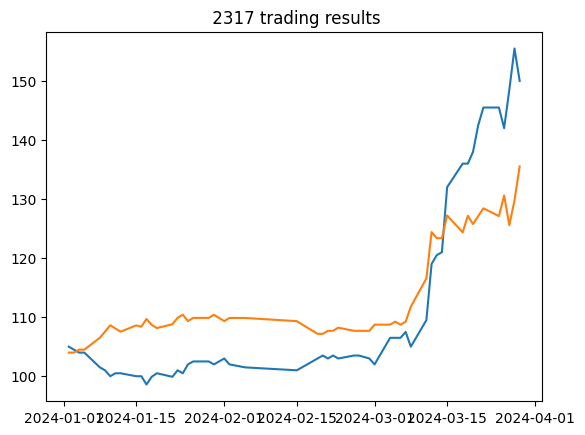

2454 聯發科 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,26,19,69,47,161,185,0.590062,0.577778,0.356164,0.002239,0.003224,"[[20230406, 0.027131782945736434], [20230407, ..."
test,9,14,13,7,43,56,0.511628,0.391304,0.562500,0.002271,-0.002241,"[[20240102, 0.028712871287128714], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,51,45,36,176,185,0.505682,0.463158,0.550000,0.001733,0.001428,"[[20230406, 0.027131782945736434], [20230407, ..."
test,16,20,12,6,54,56,0.518519,0.444444,0.727273,0.005074,0.003129,"[[20240102, 0.028712871287128714], [20240103, ..."


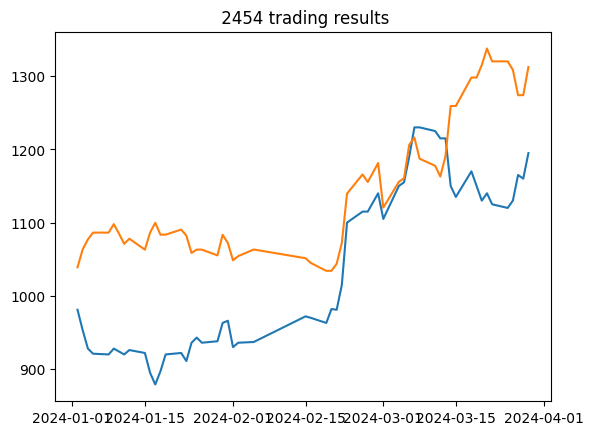

2382 廣達 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,68,55,25,21,169,185,0.550296,0.552846,0.764045,0.003221,0.003411,"[[20230406, 0], [20230407, 0.00559910414333706..."
test,22,18,9,5,54,56,0.574074,0.550000,0.814815,0.001648,0.001242,"[[20240102, 0], [20240103, -0.0214797136038186..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,71,17,13,182,185,0.538462,0.532895,0.861702,0.004315,0.003731,"[[20230406, 0.00897867564534244], [20230407, 0..."
test,26,24,5,1,56,56,0.553571,0.520000,0.962963,0.002810,0.000930,"[[20240102, -0.0467706013363029], [20240103, 0..."


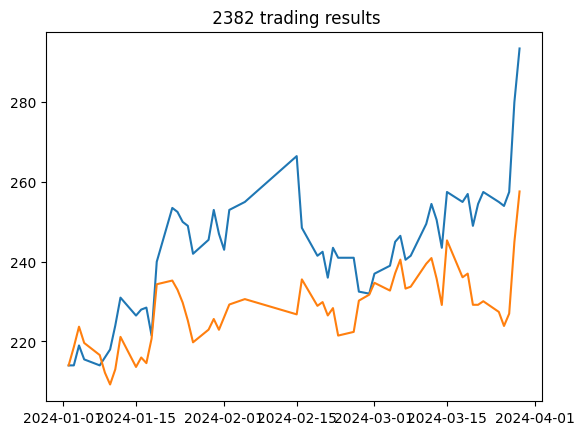

3231 緯創 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,78,9,2,170,185,0.529412,0.509434,0.975904,0.004205,0.003515,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,21,30,1,2,54,56,0.407407,0.411765,0.913043,-0.003178,-0.003772,"[[20240102, -0.04969574036511148], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,63,62,31,18,174,185,0.540230,0.504000,0.777778,0.007941,0.006097,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,16,28,4,7,55,56,0.363636,0.363636,0.695652,-0.006030,-0.006414,"[[20240102, -0.04969574036511148], [20240103, ..."


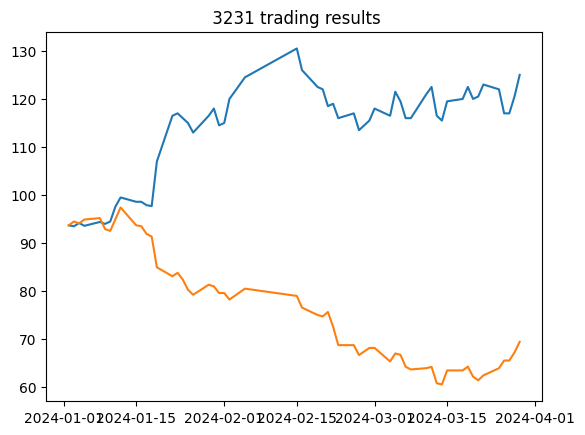

AAPL Apple Inc. us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,72,47,31,35,185,188,0.556757,0.605042,0.672897,0.001189,0.001683,"[[20230403, 0.011566323735313673], [20230404, ..."
test,12,16,16,15,59,61,0.474576,0.428571,0.444444,-0.000211,0.000210,"[[20240102, -0.008068394336094145], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,75,46,30,34,185,188,0.567568,0.619835,0.688073,0.001423,0.001934,"[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,16,15,61,61,0.475410,0.433333,0.464286,-0.000280,0.000042,"[[20240102, -0.008068394336094145], [20240103,..."


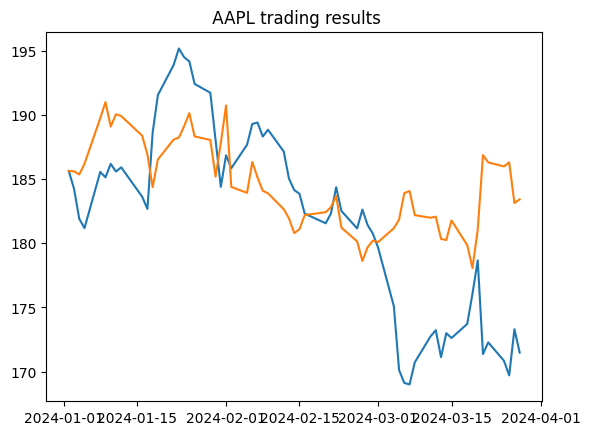

GOOGL Google us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,48,30,54,51,183,188,0.557377,0.615385,0.484848,0.001719,0.003503,"[[20230403, 0.019240160171891774], [20230404, ..."
test,8,5,20,28,61,61,0.459016,0.615385,0.222222,0.000576,0.003564,"[[20240102, 0.002742692168892269], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,29,54,51,184,188,0.565217,0.632911,0.49505,0.001907,0.003976,"[[20230403, 0.019240160171891774], [20230404, ..."
test,7,6,18,28,59,61,0.423729,0.538462,0.20000,-0.000196,0.001683,"[[20240102, 0.002742692168892269], [20240103, ..."


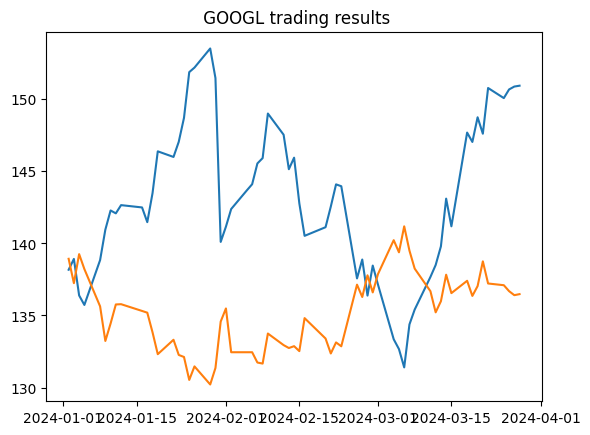

MSFT Microsoft us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,42,40,46,178,188,0.505618,0.543478,0.520833,-0.000668,-0.000221,"[[20230403, 0.002478012006142805], [20230404, ..."
test,21,24,6,8,59,61,0.457627,0.466667,0.724138,-0.001649,-0.000901,"[[20240102, -0.007997646177713607], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,56,46,32,43,177,188,0.497175,0.549020,0.565657,-0.000435,0.000299,"[[20230403, 0.002478012006142805], [20230404, ..."
test,21,24,5,9,59,61,0.440678,0.466667,0.700000,-0.001750,-0.000901,"[[20240102, -0.007997646177713607], [20240103,..."


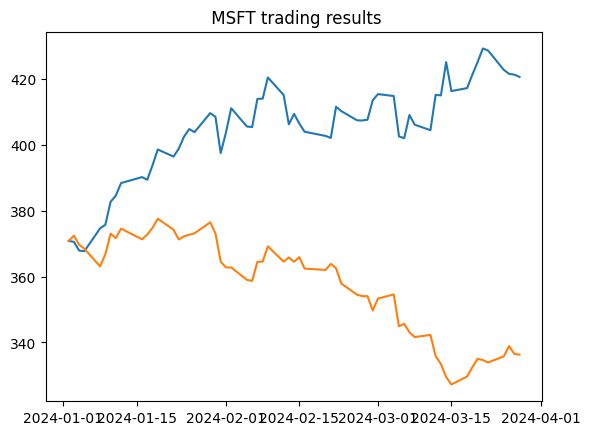

AMZN Amazon inc. us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,40,41,53,184,188,0.494565,0.555556,0.485437,-0.001023,0.000034,"[[20230403, -0.0010752688172042957], [20230404..."
test,20,15,9,16,60,61,0.483333,0.571429,0.555556,-0.000222,0.001480,"[[20240102, -0.010624257621749936], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,45,36,39,49,169,188,0.497041,0.555556,0.478723,-0.000435,0.000372,"[[20230403, -0.0010752688172042957], [20230404..."
test,19,11,9,16,55,61,0.509091,0.633333,0.542857,0.000285,0.002694,"[[20240102, 0], [20240103, -0.0048927613941018..."


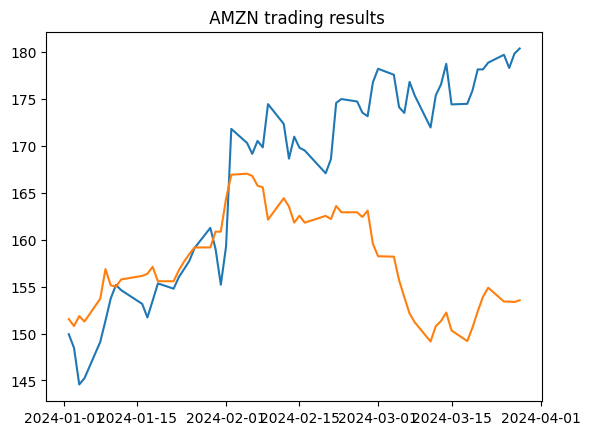

TSLA Tesla us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,42,30,54,59,185,188,0.518919,0.583333,0.415842,0.001147,0.002907,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,5,6,26,22,59,61,0.525424,0.454545,0.185185,0.001588,0.001646,"[[20240102, 0.00663787587971859], [20240103, 0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,40,31,53,57,181,188,0.513812,0.563380,0.412371,0.001311,0.002984,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,3,6,27,23,59,61,0.508475,0.333333,0.115385,0.000587,-0.003631,"[[20240102, 0.00663787587971859], [20240103, 0..."


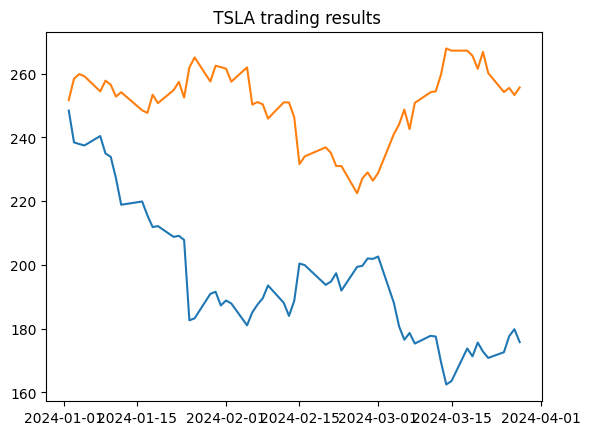

NVDA Nvidia us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,65,55,34,24,178,188,0.556180,0.541667,0.730337,0.001477,0.001107,"[[20230403, -0.016576393180413665], [20230404,..."
test,25,19,5,10,59,61,0.508475,0.568182,0.714286,-0.001149,0.001512,"[[20240102, -0.02185037771099018], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,72,56,25,21,174,188,0.557471,0.562500,0.774194,0.002136,0.002075,"[[20230403, -0.016576393180413665], [20230404,..."
test,27,19,4,7,57,61,0.543860,0.586957,0.794118,0.000019,0.001995,"[[20240102, -0.02185037771099018], [20240103, ..."


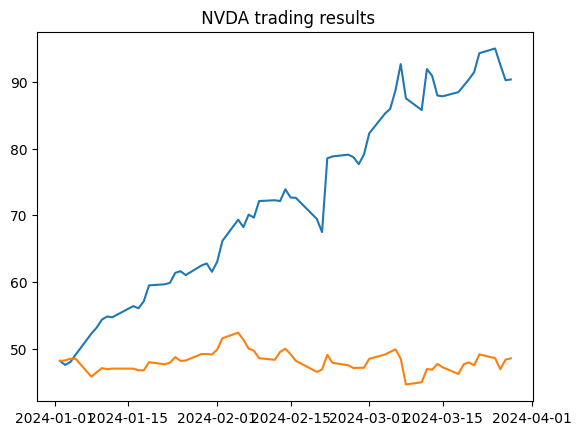

In [2]:
from factor import StockFactor

for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    stock_factor = StockFactor(env)
    
    stock_factor.generate_factors(llm4o)
    stock_factor.expand_factors(llm_factors=llm)
    train_datarange, test_datarange = split_expand(env)

    re_run = False # 是否重新訓練，True:刪除原有資料
    mode = 0
    df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)
    mode = 1
    df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)

    stock_factor.plot_acumulated_return()

## 顯示所有

In [3]:
import os
import json
import pandas as pd

env = {
    "start_date" : "20230401",
    "end_date" : "20240331",
    
    # "start_date" : "20230701",
    # "end_date" : "20240630",
    
    # "start_date" : "20231001",
    # "end_date" : "20240930",
}
path_out = "out_stock/GA_factor_" + env['start_date'] + "_" + env['end_date'] + "/"

folders = os.listdir(path_out)
results = []
index = []

for folder in folders:
    if folder == "factors_eng.json" or folder == "factors.json" or folder == "old_expand" or folder == ".DS_Store":
        continue
    folders_result = os.listdir(f"{path_out}{folder}")
    # print(f"{folder}:")
    for file in folders_result:
        if file == "factors.json" or file == "factors1.json" or file == "factors2.json" or file == "expand.json" or file == "expand1.json" or file == "expand2.json":
            continue
        path = f"{path_out}{folder}/{file}/result.json"
        with open(path, 'r') as f:
            json_data = json.load(f)
        # print(json_data)
        results.append(json_data['test'])
        index.append(f"{folder}_{file}")


# print(f"共有 {len(results), len(index)} 筆資料")
# print(results)

df = pd.DataFrame(results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
# 計算平均值
average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
df_selected = df.loc[:, selected_columns]
df_sorted = df_selected.sort_index()

display(df_sorted)
display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ac,44.64%,45.28%,0.003249,0.003466,56,24,29,1,2
2317_ev,50.00%,64.29%,0.004967,0.014982,54,9,5,18,22
2330_ac,51.11%,44.44%,0.001002,0.000225,45,16,20,7,2
2330_ev,57.14%,48.65%,0.001634,0.000606,49,18,19,10,2
2382_ac,57.41%,55.00%,0.001648,0.001242,54,22,18,9,5
2382_ev,55.36%,52.00%,0.002810,0.000930,56,26,24,5,1
2454_ac,51.16%,39.13%,0.002271,-0.002241,43,9,14,13,7
2454_ev,51.85%,44.44%,0.005074,0.003129,54,16,20,12,6
3231_ac,40.74%,41.18%,-0.003178,-0.003772,54,21,30,1,2
3231_ev,36.36%,36.36%,-0.006030,-0.006414,55,16,28,4,7


accuracy        0.489432
precision       0.491120
ev              0.000502
precision_ev    0.000979
dtype: float64

# Factor embedding

2330 台積電 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,64,67,30,15,176,185,0.534091,0.488550,0.810127,0.001394,0.000716,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,22,25,5,1,53,56,0.509434,0.468085,0.956522,0.001297,0.000565,"[[20240102, 0.005084745762711864], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,54,58,33,21,166,185,0.524096,0.482143,0.720000,0.001750,0.000980,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,22,23,7,2,54,56,0.537037,0.488889,0.916667,0.001571,0.000768,"[[20240102, 0.005084745762711864], [20240103, ..."


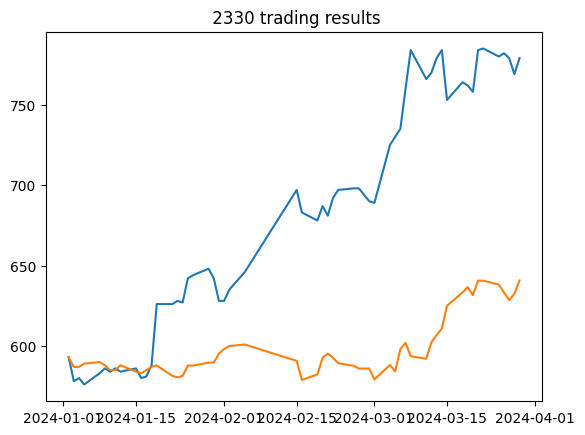

2317 鴻海 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,63,95,15,9,182,185,0.428571,0.398734,0.875000,0.000641,-0.000188,"[[20230406, -0.009569377990430622], [20230407,..."
test,24,29,1,2,56,56,0.446429,0.452830,0.923077,0.003249,0.003466,"[[20240102, 0.004784688995215311], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,13,21,63,75,172,185,0.441860,0.382353,0.147727,0.001285,-0.000154,"[[20230406, 0.009569377990430622], [20230407, ..."
test,8,5,18,23,54,56,0.481481,0.615385,0.258065,0.004700,0.015395,"[[20240102, -0.004784688995215311], [20240103,..."


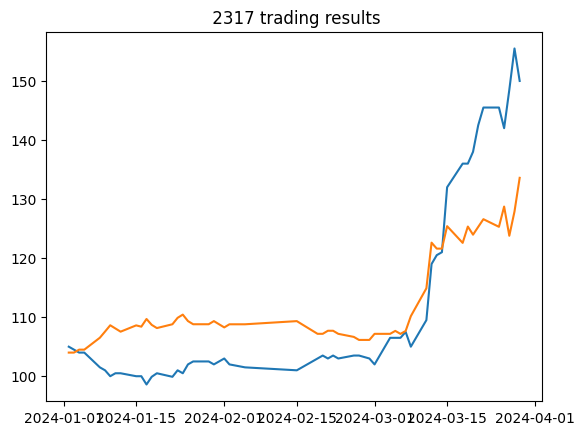

2454 聯發科 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,52,31,18,151,185,0.536424,0.490196,0.735294,0.002002,0.001429,"[[20230406, 0.027131782945736434], [20230407, ..."
test,12,18,8,6,44,56,0.454545,0.400000,0.666667,-0.001576,-0.001543,"[[20240102, 0.028712871287128714], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,51,45,36,176,185,0.505682,0.463158,0.550000,0.001733,0.001428,"[[20230406, 0.027131782945736434], [20230407, ..."
test,16,20,12,6,54,56,0.518519,0.444444,0.727273,0.005074,0.003129,"[[20240102, 0.028712871287128714], [20240103, ..."


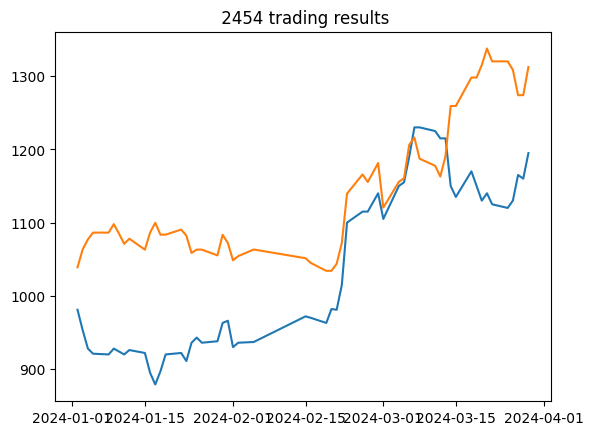

2382 廣達 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,63,52,27,22,164,185,0.548780,0.547826,0.741176,0.003508,0.003791,"[[20230406, -0.00897867564534244], [20230407, ..."
test,20,17,11,7,55,56,0.563636,0.540541,0.740741,0.002159,0.001113,"[[20240102, 0.0467706013363029], [20240103, -0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,80,70,18,13,181,185,0.541436,0.533333,0.860215,0.004201,0.003325,"[[20230406, 0.00897867564534244], [20230407, 0..."
test,25,24,5,2,56,56,0.535714,0.510204,0.925926,0.002043,0.000511,"[[20240102, -0.0467706013363029], [20240103, -..."


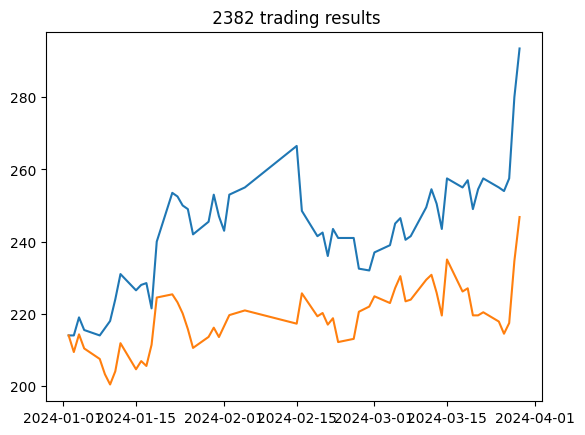

3231 緯創 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,82,82,9,1,174,185,0.522989,0.500000,0.987952,0.003969,0.002814,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,22,30,1,1,54,56,0.425926,0.423077,0.956522,-0.003062,-0.003660,"[[20240102, -0.04969574036511148], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,65,64,29,18,176,185,0.534091,0.503876,0.783133,0.007342,0.005619,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,16,28,4,7,55,56,0.363636,0.363636,0.695652,-0.006030,-0.006414,"[[20240102, -0.04969574036511148], [20240103, ..."


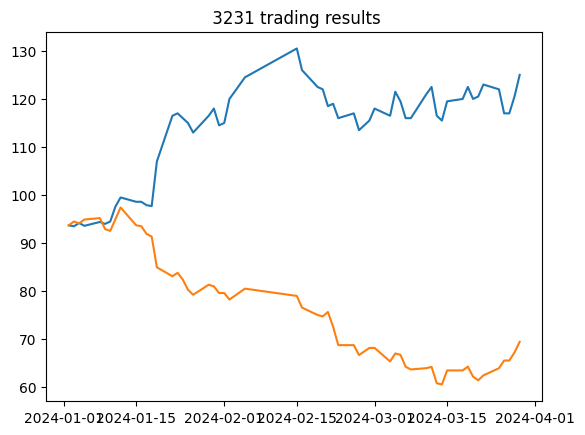

AAPL Apple Inc. us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,75,46,30,35,186,188,0.564516,0.619835,0.681818,0.00137,0.001934,"[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,16,15,61,61,0.475410,0.433333,0.464286,-0.00028,0.000042,"[[20240102, -0.008068394336094145], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,82,52,24,24,182,188,0.582418,0.611940,0.773585,0.001892,0.002013,"[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,16,12,58,61,0.500000,0.433333,0.520000,-0.000084,0.000042,"[[20240102, -0.008068394336094145], [20240103,..."


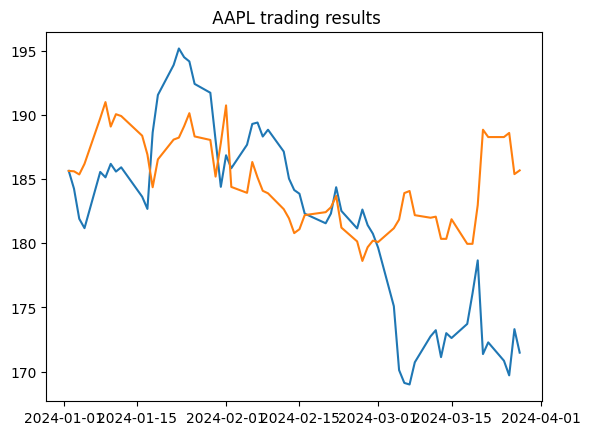

GOOGL Google us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,51,32,48,47,178,188,0.556180,0.614458,0.520408,0.001509,0.003563,"[[20230403, 0.019240160171891774], [20230404, ..."
test,9,5,19,24,57,61,0.491228,0.642857,0.272727,0.001724,0.004597,"[[20240102, 0.002742692168892269], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,27,55,52,178,188,0.556180,0.619718,0.458333,0.002011,0.004322,"[[20230403, 0.019240160171891774], [20230404, ..."
test,7,5,19,29,60,61,0.433333,0.583333,0.194444,-0.000225,0.001994,"[[20240102, 0.002742692168892269], [20240103, ..."


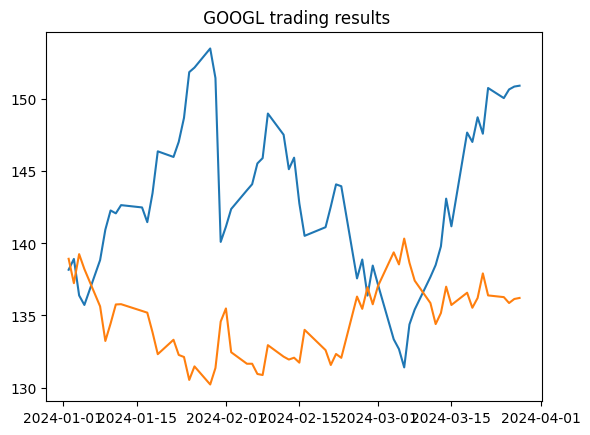

MSFT Microsoft us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,47,41,45,52,185,188,0.497297,0.534091,0.474747,-0.000953,-0.000425,"[[20230403, 0.002478012006142805], [20230404, ..."
test,21,23,7,10,61,61,0.459016,0.477273,0.677419,-0.001735,-0.000755,"[[20240102, -0.007997646177713607], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,52,42,37,44,175,188,0.508571,0.553191,0.541667,-0.000365,0.000144,"[[20230403, 0.002478012006142805], [20230404, ..."
test,20,23,5,9,57,61,0.438596,0.465116,0.689655,-0.001895,-0.001054,"[[20240102, 0], [20240103, 0.00430882631907003..."


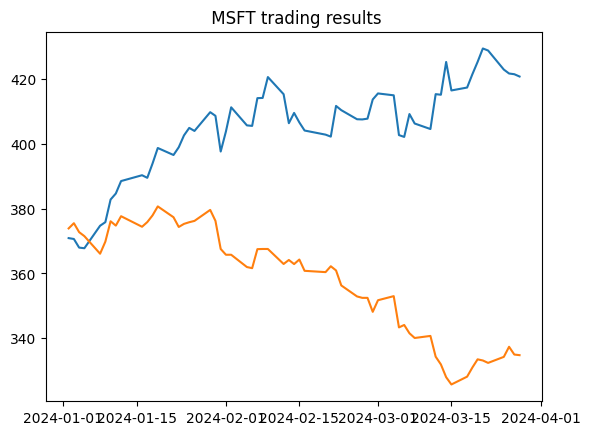

AMZN Amazon inc. us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,41,42,53,186,188,0.494624,0.549451,0.485437,-0.001025,-0.000044,"[[20230403, -0.0010752688172042957], [20230404..."
test,20,14,9,16,59,61,0.491525,0.588235,0.555556,-0.000032,0.001861,"[[20240102, -0.010624257621749936], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,19,20,60,74,173,188,0.456647,0.487179,0.204301,-0.001338,-0.001564,"[[20230403, -0.0010752688172042957], [20230404..."
test,10,6,16,21,53,61,0.490566,0.625000,0.322581,-0.001074,0.000817,"[[20240102, 0.010624257621749936], [20240103, ..."


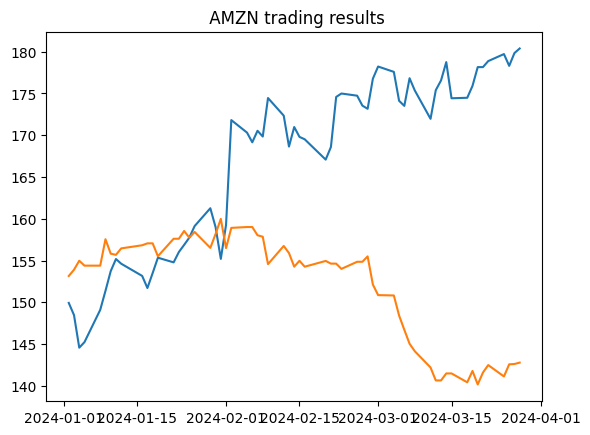

TSLA Tesla us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,34,31,54,65,184,188,0.478261,0.523077,0.343434,0.000348,0.001882,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,3,5,29,24,61,61,0.524590,0.375000,0.111111,0.000645,-0.003468,"[[20240102, 0.00663787587971859], [20240103, 0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,30,28,54,67,179,188,0.469274,0.517241,0.309278,-0.000603,0.000022,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,2,5,29,22,58,61,0.534483,0.285714,0.083333,0.001415,-0.005118,"[[20240102, 0.00663787587971859], [20240103, 0..."


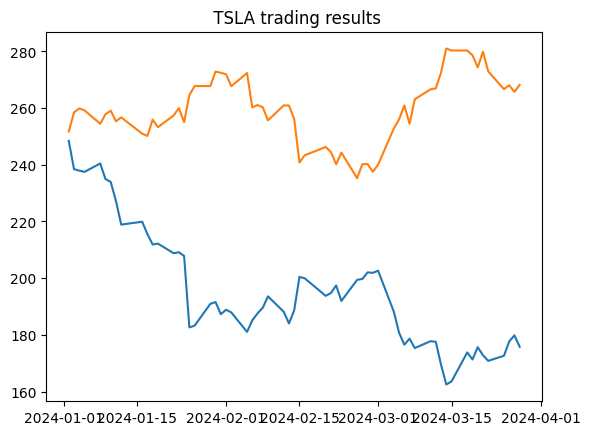

NVDA Nvidia us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,54,50,26,22,152,188,0.526316,0.519231,0.710526,0.000853,0.000326,"[[20230403, -0.016576393180413665], [20230404,..."
test,27,20,4,7,58,61,0.534483,0.574468,0.794118,-0.000130,0.002021,"[[20240102, -0.02185037771099018], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,73,63,25,22,183,188,0.535519,0.536765,0.768421,0.000961,0.001195,"[[20230403, -0.016576393180413665], [20230404,..."
test,29,21,4,7,61,61,0.540984,0.580000,0.805556,0.000562,0.002500,"[[20240102, -0.02185037771099018], [20240103, ..."


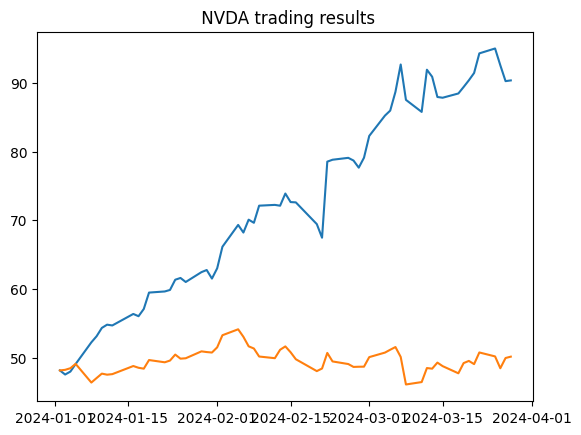

In [4]:
from factor_embd import FactorEmb

for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }

    print(env['stock_id'], env['stock_name'], env['country'])


    factor_embd = FactorEmb(env)
    factor_embd.generate_factors(llm4o)
    factor_embd.expand_factors(llm_factors=llm)
    train_datarange, test_datarange = split_expand(env)

    re_run = False # 是否重新訓練，True:刪除原有資料
    mode = 0
    df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)
    mode = 1
    df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)

    factor_embd.plot_acumulated_return()


In [5]:
import os
import json
import pandas as pd

env = {
    "start_date" : "20230401",
    "end_date" : "20240331",
    
    # "start_date" : "20230701",
    # "end_date" : "20240630",
    
    # "start_date" : "20231001",
    # "end_date" : "20240930",
}
path_out = "out_stock/Embd_" + env['start_date'] + "_" + env['end_date'] + "/"

folders = os.listdir(path_out)
results = []
index = []

for folder in folders:
    if folder == "factors_eng.json" or folder == "factors.json" or folder == "old_expand" or folder == ".DS_Store":
        continue
    folders_result = os.listdir(f"{path_out}{folder}")
    # print(f"{folder}:")
    for file in folders_result:
        if file == "factors.json" or file == "factors1.json" or file == "embeddings.json" or file == "expand.json" or file == "expand1.json" or file == "expand2.json" or file == "clustered_summaries.json":
            continue
        path = f"{path_out}{folder}/{file}/result.json"
        with open(path, 'r') as f:
            json_data = json.load(f)
        # print(json_data)
        results.append(json_data['test'])
        index.append(f"{folder}_{file}")


# print(f"共有 {len(results), len(index)} 筆資料")
# print(results)

df = pd.DataFrame(results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
# 計算平均值
average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
df_selected = df.loc[:, selected_columns]
df_sorted = df_selected.sort_index()

display(df_sorted)
display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ac,44.64%,45.28%,0.003249,0.003466,56,24,29,1,2
2317_ev,48.15%,61.54%,0.004700,0.015395,54,8,5,18,23
2330_ac,50.94%,46.81%,0.001297,0.000565,53,22,25,5,1
2330_ev,53.70%,48.89%,0.001571,0.000768,54,22,23,7,2
2382_ac,56.36%,54.05%,0.002159,0.001113,55,20,17,11,7
2382_ev,53.57%,51.02%,0.002043,0.000511,56,25,24,5,2
2454_ac,45.45%,40.00%,-0.001576,-0.001543,44,12,18,8,6
2454_ev,51.85%,44.44%,0.005074,0.003129,54,16,20,12,6
3231_ac,42.59%,42.31%,-0.003062,-0.003660,54,22,30,1,1
3231_ev,36.36%,36.36%,-0.006030,-0.006414,55,16,28,4,7


accuracy        0.488662
precision       0.489580
ev              0.000378
precision_ev    0.000764
dtype: float64